# MNIST: Tree Ensemble Methods

## Project Overview

This notebook develops tree ensembles from individual decision trees and compares manual voting strategies with several ensemble implementations.

The analysis progresses from a single deterministic tree to randomized trees, hard voting, probability averaging, random feature subsets, bootstrap sampling, Random Forests, Extra Trees, gradient boosting, histogram-based gradient boosting, and XGBoost.

### Technical Coverage

- single decision-tree baselines
- random splitters
- hard-voting ensembles
- entropy and Gini criteria
- random feature subsets
- bootstrap sampling
- probability averaging
- ensemble-size analysis
- RandomForestClassifier
- feature importance
- ExtraTreesClassifier
- GradientBoostingClassifier
- HistGradientBoostingClassifier
- XGBoost
- optional GPU acceleration

## 1. Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.model_selection import train_test_split
import tensorflow as tf


## 2. MNIST Data Preparation

The MNIST images are normalized to the `[0, 1]` range and flattened from 28×28 images into 784-dimensional vectors.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


## 3. Single-Tree Baselines

A conventional entropy-based decision tree establishes the single-model reference point.

In [4]:
model = DecisionTreeClassifier(criterion='entropy')
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

Accuracy 0.8872


### Raw Feature-Importance Vector

The fitted tree exposes one importance value for each of the 784 input pixels.

In [5]:
model.feature_importances_

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

### Random Splitter

Changing the splitter from `best` to `random` creates diversity between independently fitted trees, which makes voting-based aggregation possible.

In [6]:
model = DecisionTreeClassifier(criterion='entropy', splitter='random')
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

Accuracy 0.8803


## 4. Manual Hard-Voting Forest with Entropy

Thirty randomized entropy trees are trained independently. Each tree contributes one class vote, and the cumulative majority vote is evaluated after every additional tree.

In [7]:
model = DecisionTreeClassifier(criterion='entropy', splitter='random')
preds = np.zeros((y_test.shape[0],10),dtype=int)
model_acc = []
ens_acc = []
for i in range(30):
  model = model.fit(x_train, y_train)
  pred = model.predict(x_test)
  preds[np.arange(y_test.shape[0]),pred]+=1
  accuracy = accuracy_score(y_test, pred)
  model_acc.append(accuracy)
  print(f'Model {i} Accuracy {accuracy:.4}')
  p = np.argmax(preds,axis=1)
  accuracy = accuracy_score(y_test, p)
  ens_acc.append(accuracy)
  print(f'Accuracy of Ensemble with {i+1} models: {accuracy:.4}')

Model 0 Accuracy 0.884
Accuracy of Ensemble with 1 models: 0.884
Model 1 Accuracy 0.8771
Accuracy of Ensemble with 2 models: 0.8821
Model 2 Accuracy 0.8808
Accuracy of Ensemble with 3 models: 0.9249
Model 3 Accuracy 0.882
Accuracy of Ensemble with 4 models: 0.9371
Model 4 Accuracy 0.8852
Accuracy of Ensemble with 5 models: 0.9478
Model 5 Accuracy 0.8794
Accuracy of Ensemble with 6 models: 0.9521
Model 6 Accuracy 0.887
Accuracy of Ensemble with 7 models: 0.9562
Model 7 Accuracy 0.8867
Accuracy of Ensemble with 8 models: 0.9589
Model 8 Accuracy 0.8871
Accuracy of Ensemble with 9 models: 0.9618
Model 9 Accuracy 0.8803
Accuracy of Ensemble with 10 models: 0.9604
Model 10 Accuracy 0.8818
Accuracy of Ensemble with 11 models: 0.9617
Model 11 Accuracy 0.881
Accuracy of Ensemble with 12 models: 0.9629
Model 12 Accuracy 0.8788
Accuracy of Ensemble with 13 models: 0.9648
Model 13 Accuracy 0.8854
Accuracy of Ensemble with 14 models: 0.9645
Model 14 Accuracy 0.8814
Accuracy of Ensemble with 15 mode

### Accuracy vs. Ensemble Size

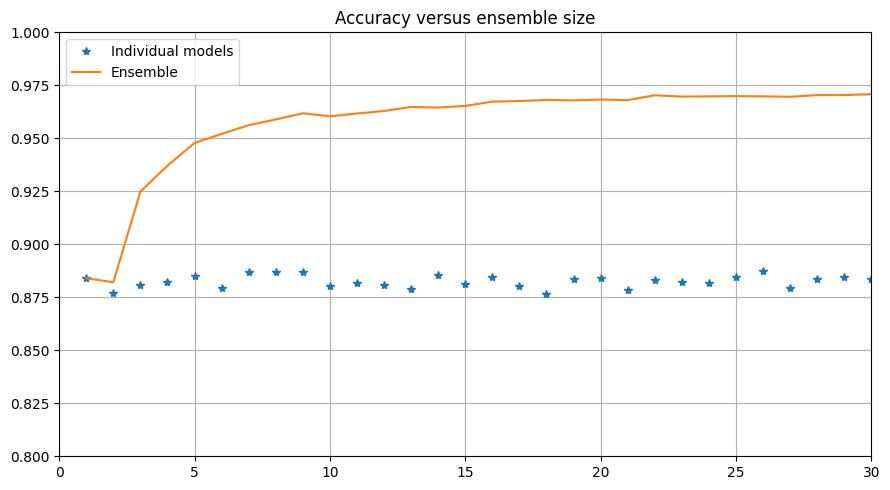

In [8]:
fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('Accuracy versus ensemble size')
plt.grid(True)
ax0.plot(np.arange(1,len(model_acc)+1), model_acc,'*',label = 'Individual models')
ax0.plot(np.arange(1,len(model_acc)+1), ens_acc,label = 'Ensemble')
ax0.legend(loc='upper left')
ax0.set_xlim(0,30)
ax0.set_ylim(0.8,1)
fig0.tight_layout()

The saved run increases from **0.8778** accuracy with the first randomized tree to **0.9701** after all 30 trees.

## 5. Manual Hard-Voting Forest with Gini Impurity

The same 30-tree randomized voting strategy is repeated with Gini impurity.

Model 0 Accuracy 0.8767
Ensemble Accuracy 0.8767
Model 1 Accuracy 0.8752
Ensemble Accuracy 0.8759
Model 2 Accuracy 0.87
Ensemble Accuracy 0.9159
Model 3 Accuracy 0.8779
Ensemble Accuracy 0.9301
Model 4 Accuracy 0.8765
Ensemble Accuracy 0.9392
Model 5 Accuracy 0.8757
Ensemble Accuracy 0.9462
Model 6 Accuracy 0.8705
Ensemble Accuracy 0.9513
Model 7 Accuracy 0.8736
Ensemble Accuracy 0.9543
Model 8 Accuracy 0.8755
Ensemble Accuracy 0.9562
Model 9 Accuracy 0.8715
Ensemble Accuracy 0.958
Model 10 Accuracy 0.8782
Ensemble Accuracy 0.9592
Model 11 Accuracy 0.8757
Ensemble Accuracy 0.96
Model 12 Accuracy 0.8791
Ensemble Accuracy 0.9607
Model 13 Accuracy 0.881
Ensemble Accuracy 0.9606
Model 14 Accuracy 0.8754
Ensemble Accuracy 0.9619
Model 15 Accuracy 0.8758
Ensemble Accuracy 0.9625
Model 16 Accuracy 0.8719
Ensemble Accuracy 0.9628
Model 17 Accuracy 0.8749
Ensemble Accuracy 0.9645
Model 18 Accuracy 0.8735
Ensemble Accuracy 0.9645
Model 19 Accuracy 0.8748
Ensemble Accuracy 0.9654
Model 20 Accurac

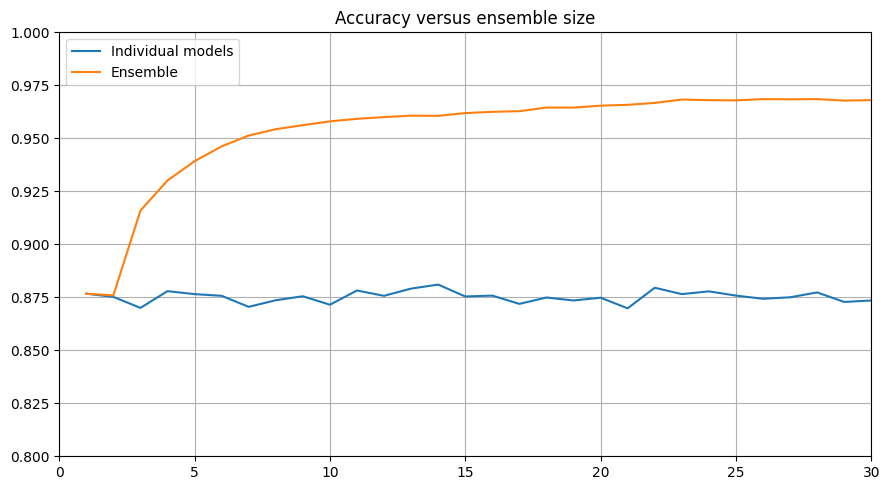

In [9]:
model = DecisionTreeClassifier(criterion='gini', splitter='random')
preds = np.zeros((y_test.shape[0],10),dtype=int)
model_acc = []
ens_acc = []
for i in range(30):
  model = model.fit(x_train, y_train)
  pred = model.predict(x_test)
  preds[np.arange(y_test.shape[0]),pred]+=1
  accuracy = accuracy_score(y_test, pred)
  model_acc.append(accuracy)
  print(f'Model {i} Accuracy {accuracy:.4}')
  p = np.argmax(preds,axis=1)
  accuracy = accuracy_score(y_test, p)
  ens_acc.append(accuracy)
  print(f'Ensemble Accuracy {accuracy:.4}')

fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('Accuracy versus ensemble size')
plt.grid(True)
ax0.plot(np.arange(1,len(model_acc)+1), model_acc,label = 'Individual models')
ax0.plot(np.arange(1,len(model_acc)+1), ens_acc,label = 'Ensemble')
ax0.legend(loc='upper left')
ax0.set_xlim(0,30)
ax0.set_ylim(0.8,1)
fig0.tight_layout()

The saved 30-tree Gini ensemble reaches **0.9676** accuracy.

## 6. Random Feature Subsets

Tree diversity can also be created by changing which input pixels are available to each tree.

### 50% of Features per Tree

Model 0 Accuracy 0.8821
Ensemble Accuracy 0.8821
Model 1 Accuracy 0.8778
Ensemble Accuracy 0.88
Model 2 Accuracy 0.8818
Ensemble Accuracy 0.9164
Model 3 Accuracy 0.8881
Ensemble Accuracy 0.9327
Model 4 Accuracy 0.8784
Ensemble Accuracy 0.9399
Model 5 Accuracy 0.8798
Ensemble Accuracy 0.9477
Model 6 Accuracy 0.8803
Ensemble Accuracy 0.9519
Model 7 Accuracy 0.8806
Ensemble Accuracy 0.9538
Model 8 Accuracy 0.8755
Ensemble Accuracy 0.9561
Model 9 Accuracy 0.8809
Ensemble Accuracy 0.9568
Model 10 Accuracy 0.877
Ensemble Accuracy 0.9584
Model 11 Accuracy 0.877
Ensemble Accuracy 0.9595
Model 12 Accuracy 0.8802
Ensemble Accuracy 0.9604
Model 13 Accuracy 0.8805
Ensemble Accuracy 0.9612
Model 14 Accuracy 0.8833
Ensemble Accuracy 0.9618
Model 15 Accuracy 0.8846
Ensemble Accuracy 0.9626
Model 16 Accuracy 0.8822
Ensemble Accuracy 0.9644
Model 17 Accuracy 0.8825
Ensemble Accuracy 0.9643
Model 18 Accuracy 0.8921
Ensemble Accuracy 0.9649
Model 19 Accuracy 0.8839
Ensemble Accuracy 0.9648
Model 20 Accur

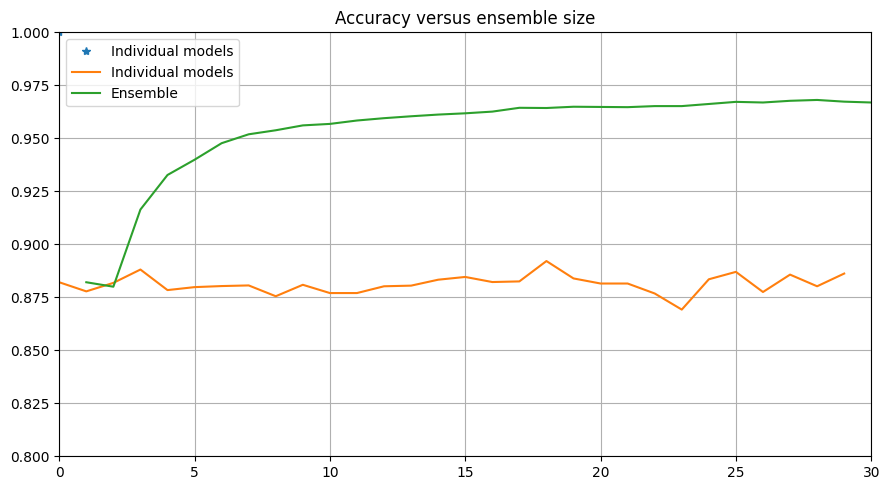

In [10]:
model = DecisionTreeClassifier(criterion='entropy')
preds = np.zeros((y_test.shape[0],10),dtype=int)
feature_pct = 0.5
model_acc = []
ens_acc = []
for i in range(30):
  features = np.random.permutation(x_train.shape[1])[:int(x_train.shape[1]*feature_pct+0.5)]
  model = model.fit(x_train[:,features], y_train)
  pred = model.predict(x_test[:,features])
  preds[np.arange(y_test.shape[0]),pred]+=1
  accuracy = accuracy_score(y_test, pred)
  model_acc.append(accuracy)
  print(f'Model {i} Accuracy {accuracy:.4}')
  p = np.argmax(preds,axis=1)
  accuracy = accuracy_score(y_test, p)
  ens_acc.append(accuracy)
  print(f'Ensemble Accuracy {accuracy:.4}')

fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('Accuracy versus ensemble size')
plt.grid(True)
ax0.plot(np.arange(1,len(model_acc)+1), '*',model_acc,label = 'Individual models')
ax0.plot(np.arange(1,len(model_acc)+1), ens_acc,label = 'Ensemble')
ax0.legend(loc='upper left')
ax0.set_xlim(0,30)
ax0.set_ylim(0.8,1)
fig0.tight_layout()

### 75% of Features per Tree

Model 0 Accuracy 0.8841
Ensemble Accuracy 0.8841
Model 1 Accuracy 0.8834
Ensemble Accuracy 0.8805
Model 2 Accuracy 0.8853
Ensemble Accuracy 0.9261
Model 3 Accuracy 0.8847
Ensemble Accuracy 0.9322
Model 4 Accuracy 0.8869
Ensemble Accuracy 0.9407
Model 5 Accuracy 0.8863
Ensemble Accuracy 0.946
Model 6 Accuracy 0.8875
Ensemble Accuracy 0.9511
Model 7 Accuracy 0.8848
Ensemble Accuracy 0.9545
Model 8 Accuracy 0.8881
Ensemble Accuracy 0.9558
Model 9 Accuracy 0.8855
Ensemble Accuracy 0.9583
Model 10 Accuracy 0.8814
Ensemble Accuracy 0.9586
Model 11 Accuracy 0.8839
Ensemble Accuracy 0.9595
Model 12 Accuracy 0.8898
Ensemble Accuracy 0.9623
Model 13 Accuracy 0.8825
Ensemble Accuracy 0.9616
Model 14 Accuracy 0.8822
Ensemble Accuracy 0.9618
Model 15 Accuracy 0.8848
Ensemble Accuracy 0.9626
Model 16 Accuracy 0.8858
Ensemble Accuracy 0.9629
Model 17 Accuracy 0.8844
Ensemble Accuracy 0.9627
Model 18 Accuracy 0.8854
Ensemble Accuracy 0.9626
Model 19 Accuracy 0.8822
Ensemble Accuracy 0.9635
Model 20 Ac

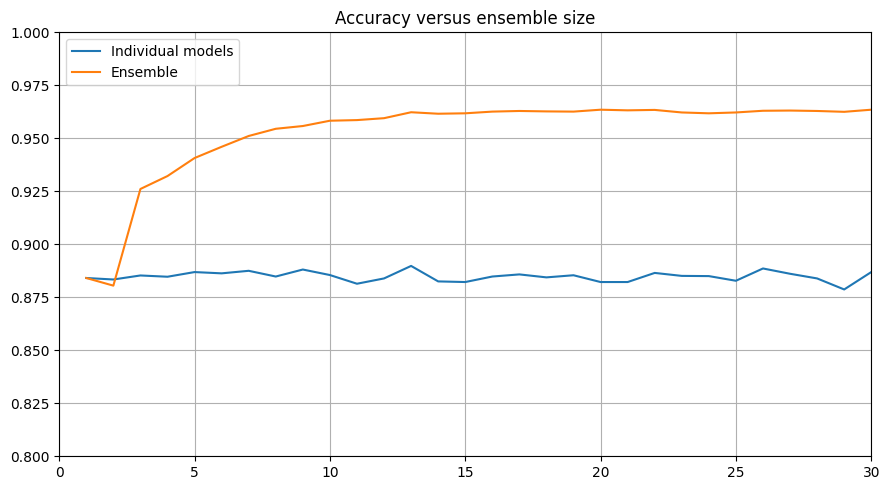

In [11]:
model = DecisionTreeClassifier(criterion='entropy')
preds = np.zeros((y_test.shape[0],10),dtype=int)
feature_pct = 0.75
model_acc = []
ens_acc = []
for i in range(30):
  features = np.random.permutation(x_train.shape[1])[:int(x_train.shape[1]*feature_pct+0.5)]
  model = model.fit(x_train[:,features], y_train)
  pred = model.predict(x_test[:,features])
  preds[np.arange(y_test.shape[0]),pred]+=1
  accuracy = accuracy_score(y_test, pred)
  model_acc.append(accuracy)
  print(f'Model {i} Accuracy {accuracy:.4}')
  p = np.argmax(preds,axis=1)
  accuracy = accuracy_score(y_test, p)
  ens_acc.append(accuracy)
  print(f'Ensemble Accuracy {accuracy:.4}')

fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('Accuracy versus ensemble size')
plt.grid(True)
ax0.plot(np.arange(1,len(model_acc)+1), model_acc,label = 'Individual models')
ax0.plot(np.arange(1,len(model_acc)+1), ens_acc,label = 'Ensemble')
ax0.legend(loc='upper left')
ax0.set_xlim(0,30)
ax0.set_ylim(0.8,1)
fig0.tight_layout()

The saved 75%-feature experiment reaches **0.9582** ensemble accuracy after 30 trees.

## 7. Bootstrap Sampling

Each tree is trained on a same-size sample drawn with replacement from the original training set. Predictions are accumulated through majority voting.

Model 0 Accuracy 0.8731
Ensemble Accuracy 0.8731
Model 1 Accuracy 0.8717
Ensemble Accuracy 0.8728
Model 2 Accuracy 0.8691
Ensemble Accuracy 0.9127
Model 3 Accuracy 0.8737
Ensemble Accuracy 0.9232
Model 4 Accuracy 0.8714
Ensemble Accuracy 0.9336
Model 5 Accuracy 0.8726
Ensemble Accuracy 0.9366
Model 6 Accuracy 0.8703
Ensemble Accuracy 0.9399
Model 7 Accuracy 0.8749
Ensemble Accuracy 0.9446
Model 8 Accuracy 0.869
Ensemble Accuracy 0.9448
Model 9 Accuracy 0.8667
Ensemble Accuracy 0.947
Model 10 Accuracy 0.8731
Ensemble Accuracy 0.9496
Model 11 Accuracy 0.8672
Ensemble Accuracy 0.9517
Model 12 Accuracy 0.8698
Ensemble Accuracy 0.953
Model 13 Accuracy 0.8724
Ensemble Accuracy 0.9532
Model 14 Accuracy 0.875
Ensemble Accuracy 0.9533
Model 15 Accuracy 0.8741
Ensemble Accuracy 0.9539
Model 16 Accuracy 0.8675
Ensemble Accuracy 0.9543
Model 17 Accuracy 0.8704
Ensemble Accuracy 0.9548
Model 18 Accuracy 0.8723
Ensemble Accuracy 0.9552
Model 19 Accuracy 0.8712
Ensemble Accuracy 0.9558
Model 20 Accur

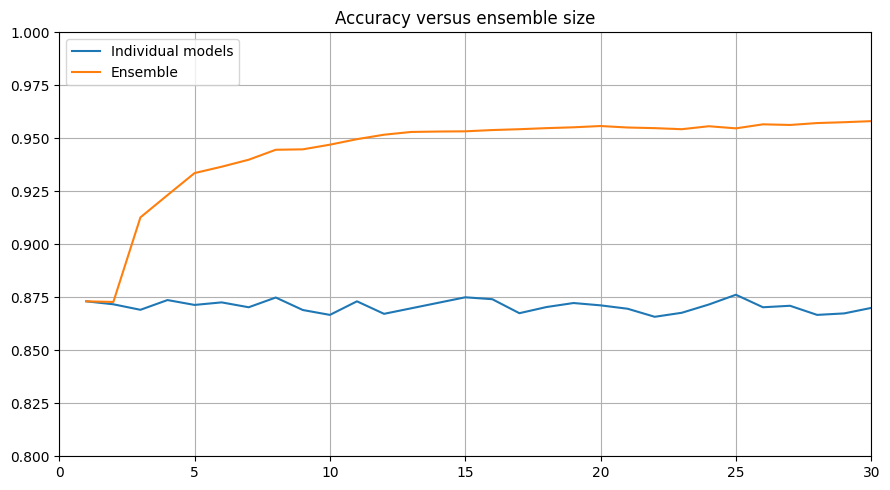

In [12]:
model = DecisionTreeClassifier(criterion='entropy')
preds = np.zeros((y_test.shape[0],10),dtype=int)
model_acc = []
ens_acc = []
for i in range(30):
  samples = np.random.randint(0,x_train.shape[0],size=x_train.shape[0])
  model = model.fit(x_train[samples], y_train[samples])
  pred = model.predict(x_test)
  preds[np.arange(y_test.shape[0]),pred]+=1
  accuracy = accuracy_score(y_test, pred)
  model_acc.append(accuracy)
  print(f'Model {i} Accuracy {accuracy:.4}')
  p = np.argmax(preds,axis=1)
  accuracy = accuracy_score(y_test, p)
  ens_acc.append(accuracy)
  print(f'Ensemble Accuracy {accuracy:.4}')

fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('Accuracy versus ensemble size')
plt.grid(True)
ax0.plot(np.arange(1,len(model_acc)+1), model_acc,label = 'Individual models')
ax0.plot(np.arange(1,len(model_acc)+1), ens_acc,label = 'Ensemble')
ax0.legend(loc='upper left')
ax0.set_xlim(0,30)
ax0.set_ylim(0.8,1)
fig0.tight_layout()

The saved bootstrap-sampling ensemble reaches **0.9581** accuracy after 30 trees.

## 8. Probability Averaging with Smaller Trees

Instead of voting only on final class labels, each depth-12 randomized tree predicts a class-probability vector. The probability vectors are summed and the class with the largest accumulated probability is selected.

Model 0 Accuracy 0.8803
Ensemble Accuracy 0.8803
Model 1 Accuracy 0.8775
Ensemble Accuracy 0.895
Model 2 Accuracy 0.878
Ensemble Accuracy 0.925
Model 3 Accuracy 0.8778
Ensemble Accuracy 0.9369
Model 4 Accuracy 0.8836
Ensemble Accuracy 0.9431
Model 5 Accuracy 0.8769
Ensemble Accuracy 0.9445
Model 6 Accuracy 0.8727
Ensemble Accuracy 0.9463
Model 7 Accuracy 0.8777
Ensemble Accuracy 0.9491
Model 8 Accuracy 0.8772
Ensemble Accuracy 0.9514
Model 9 Accuracy 0.8768
Ensemble Accuracy 0.9522
Model 10 Accuracy 0.8797
Ensemble Accuracy 0.953
Model 11 Accuracy 0.8685
Ensemble Accuracy 0.9533
Model 12 Accuracy 0.8726
Ensemble Accuracy 0.9544
Model 13 Accuracy 0.8777
Ensemble Accuracy 0.9542
Model 14 Accuracy 0.8812
Ensemble Accuracy 0.9545
Model 15 Accuracy 0.8804
Ensemble Accuracy 0.9565
Model 16 Accuracy 0.8798
Ensemble Accuracy 0.9571
Model 17 Accuracy 0.8806
Ensemble Accuracy 0.9574
Model 18 Accuracy 0.879
Ensemble Accuracy 0.9581
Model 19 Accuracy 0.8743
Ensemble Accuracy 0.9579
Model 20 Accura

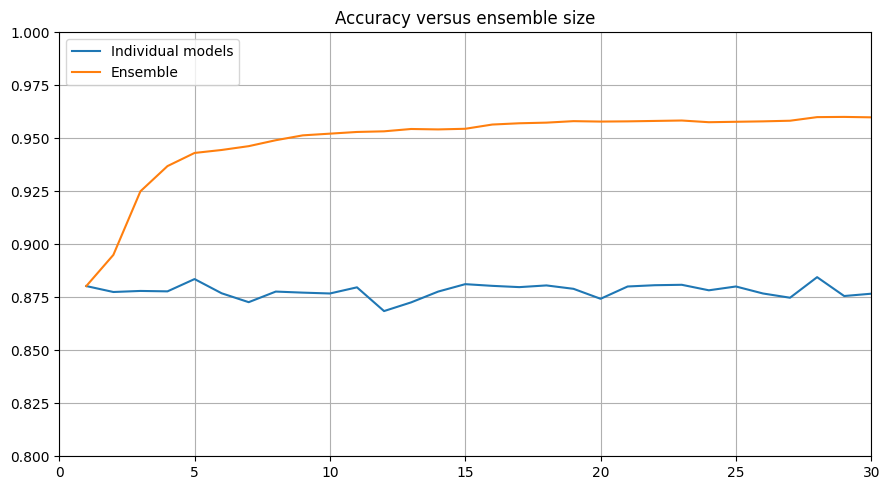

In [13]:
model = DecisionTreeClassifier(criterion='entropy', max_depth = 12, splitter='random')
preds = np.zeros((y_test.shape[0],10),dtype=int)
model_acc = []
ens_acc = []
pred_prob_sum = 0
for i in range(30):
  model = model.fit(x_train, y_train)
  pred_prob = model.predict_proba(x_test)
  pred = np.argmax(pred_prob,axis=1)
  pred_prob_sum += pred_prob
  accuracy = accuracy_score(y_test, pred)
  model_acc.append(accuracy)
  print(f'Model {i} Accuracy {accuracy:.4}')
  p = np.argmax(pred_prob_sum,axis=1)
  accuracy = accuracy_score(y_test, p)
  ens_acc.append(accuracy)
  print(f'Ensemble Accuracy {accuracy:.4}')

fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('Accuracy versus ensemble size')
plt.grid(True)
ax0.plot(np.arange(1,len(model_acc)+1), model_acc,label = 'Individual models')
ax0.plot(np.arange(1,len(model_acc)+1), ens_acc,label = 'Ensemble')
ax0.legend(loc='upper left')
ax0.set_xlim(0,30)
ax0.set_ylim(0.8,1)
fig0.tight_layout()

The saved probability-averaging ensemble reaches **0.9620** accuracy after 30 trees.

## 9. Random Forest Classifier

The library implementation provides the same general randomized-tree ensemble strategy in a compact estimator.

### 30 Trees

In [14]:
model = RandomForestClassifier(n_estimators=30, criterion='entropy',n_jobs=-1)
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

Accuracy 0.9642


### 100 Trees

In [15]:
model = RandomForestClassifier(n_estimators=100, criterion='entropy',n_jobs=-1)
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

Accuracy 0.9678


Increasing the saved forest size from 30 to 100 trees improves accuracy from **0.9634** to **0.9693**.

### Random Forest Feature-Importance Map

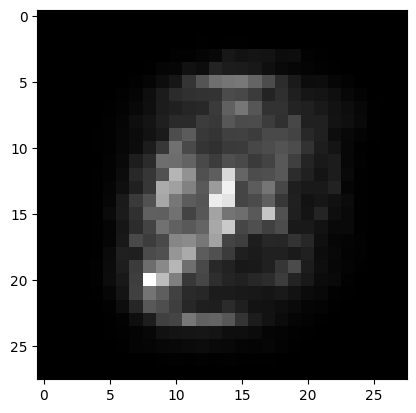

In [16]:
plt.figure()
plt.imshow(model.feature_importances_.reshape(28,28),cmap='gray')
plt.show()

## 10. Extra Trees

Extremely randomized trees introduce additional split randomness.

In [17]:
model = ExtraTreesClassifier(n_estimators=30, criterion='entropy', n_jobs=-1)
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

Accuracy 0.9665


The saved 30-tree Extra Trees model reaches **0.9665** accuracy.

## 11. Gradient Boosting

Gradient boosting builds trees sequentially so later models correct errors made by earlier models.

In [18]:
model = GradientBoostingClassifier(n_estimators=30, verbose=2)
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

      Iter       Train Loss   Remaining Time 
         1           1.9103           12.64m
         2           1.6843           12.24m
         3           1.5170           11.84m
         4           1.3837           11.45m
         5           1.2679           11.02m
         6           1.1712           10.58m
         7           1.0834           10.17m
         8           1.0090            9.72m
         9           0.9433            9.28m
        10           0.8849            8.85m
        11           0.8351            8.41m
        12           0.7896            7.96m
        13           0.7467            7.52m
        14           0.7091            7.08m
        15           0.6776            6.64m
        16           0.6472            6.20m
        17           0.6217            5.76m
        18           0.5965            5.32m
        19           0.5729            4.88m
        20           0.5524            4.43m
        21           0.5327            3.99m
        2

The saved 30-stage GradientBoostingClassifier reaches **0.9057** accuracy.

## 12. Histogram-Based Gradient Boosting

Histogram-based gradient boosting discretizes continuous feature values into bins to accelerate tree construction.

In [19]:
model = HistGradientBoostingClassifier(max_iter=30, verbose=1)
model = model.fit(x_train, y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')

Binning 0.339 GB of training data: 1.637 s
Binning 0.038 GB of validation data: 0.096 s
Fitting gradient boosted rounds:
Fit 300 trees in 114.990 s, (9300 total leaves)
Time spent computing histograms: 102.906s
Time spent finding best splits:  8.635s
Time spent applying splits:      0.558s
Time spent predicting:           0.034s
Accuracy 0.9614


The saved 30-iteration HistGradientBoostingClassifier reaches **0.9618** accuracy.

## 13. XGBoost

A 30-estimator XGBoost classifier provides another boosted-tree implementation.

In [20]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=30)
model.fit(x_train, y_train)

pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4f}')


Accuracy 0.9678


The saved CPU XGBoost experiment reaches **0.9670** accuracy.

### Optional GPU-Accelerated XGBoost

The same model can request CUDA acceleration when a compatible GPU runtime is available.

In [21]:
from xgboost import XGBClassifier

try:
    model_gpu = XGBClassifier(
        n_estimators=30,
        tree_method="hist",
        device="cuda",
    )
    model_gpu.fit(x_train, y_train)

    pred_gpu = model_gpu.predict(x_test)
    accuracy_gpu = accuracy_score(y_test, pred_gpu)
    print(f'GPU-accelerated XGBoost accuracy {accuracy_gpu:.4f}')
except Exception as exc:
    print("GPU acceleration is not available in this runtime.")
    print(type(exc).__name__)


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [18:13:34] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [18:13:34] WARNING: /__w/xgboost/xgboost/src/context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


GPU-accelerated XGBoost accuracy 0.9678


## 14. Comparative Results

| Method | Saved Accuracy |
|---|---:|
| Single decision tree — entropy | 0.8868 |
| Single decision tree — entropy + random splitter | 0.8780 |
| Manual 30-tree hard voting — entropy | **0.9701** |
| Manual 30-tree hard voting — Gini | 0.9676 |
| Manual 30-tree random 75% feature subsets | 0.9582 |
| Manual 30-tree bootstrap sampling | 0.9581 |
| Manual 30-tree probability averaging | 0.9620 |
| Random Forest — 30 trees | 0.9634 |
| Random Forest — 100 trees | 0.9693 |
| Extra Trees — 30 trees | 0.9665 |
| Gradient Boosting — 30 stages | 0.9057 |
| Histogram Gradient Boosting — 30 iterations | 0.9618 |
| XGBoost — 30 estimators | 0.9670 |

## 15. Key Findings

- Independent randomized trees are substantially weaker than their aggregated ensemble.
- Hard voting improves rapidly as additional randomized trees are added.
- Entropy and Gini both support strong manual voting ensembles.
- Random feature subsets and bootstrap samples create useful model diversity.
- Probability averaging allows shallower trees to contribute soft class evidence.
- Increasing the number of Random Forest estimators improves the saved MNIST result.
- Extra Trees and XGBoost achieve performance close to the strongest tree ensembles in the saved comparisons.